# **BEV 3D Keypoints Stereo Distance**

## **Pipeline**
* Use BEV to get 2D keypoints (pixel coordinates) and 3D keypoints (unscaled camera coordinates)
* Use StereoSGBM to get distance from camera to shoulder joint
* Place 3D keypoints at calculated distance (camera coordinates)
* Convert 3D keypoints to Unreal Engine camera coordinates
* Render pose visualization
* Compute output vectors

### **Setup**

```
conda create -n fbv-bev python=3.9
conda activate fbv-bev
conda install matplotlib
pip install mediapipe opencv-python
pip install ipympl
conda install ipykernel=6.29.5
```

In [94]:
import bev
import cv2
import numpy as np
import time
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [95]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [96]:
%matplotlib widget

In [97]:
IMAGE_A_PATH = "../../../dataset/images_A/00101A.png"
IMAGE_B_PATH = "../../../dataset/images_B/00101B.png"
MODEL_PATH = "../../models/pose_landmarker_full.task"

FOCAL_LENGTH_MM = 35.0
SENSOR_WIDTH_MM = 36.0 
BASELINE_M = 0.1

### **BEV Initialization**

In [98]:
# Configure BEV Settings

settings = bev.main.default_settings
settings.mode = 'image'
settings.render_mesh = False  # Skip the 3D mesh creation
settings.show = False         # Skip opening a display window
settings.save_dict = False    # Skip saving .npz files to disk

In [99]:
# Load BEV Model

bev_model = bev.BEV(settings)

Using BEV.
Threshold for positive center detection: 0.08


In [100]:
def get_output(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    outputs = bev_model(img)
        
    return outputs

### **Run Inference**

In [101]:
# Run Model On Given File

image_file = IMAGE_A_PATH
start_time = time.perf_counter()

outputs = get_output(image_file)

joints = outputs['joints']
if hasattr(joints, 'detach'):
    joints =  data.detach().cpu().numpy()

end_time = time.perf_counter()

if joints is not None:
    print(f"Detected {len(joints)} people.")
    print(f"First person Pelvis (X, Y, Z): {joints[0][0]}")

execution_time = end_time - start_time
print(f"Detection took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Detected 1 people.
First person Pelvis (X, Y, Z): [-0.00836042  0.02169861  0.01750791]
Detection took: 1.5056 seconds
FPS: 0.66


In [102]:
#   Get 2D Keypoints

def get_normalized_2d_keypoints(outputs, person_idx=0):
    cam = outputs['cam'][person_idx]
    if hasattr(cam, 'detach'):
        cam = cam.detach().cpu().numpy()
        
    scale = cam[0]
    trans = cam[1:3]

    joints_3d = outputs['joints'][person_idx]
    if hasattr(joints_3d, 'detach'):
        joints_3d = joints_3d.detach().cpu().numpy()
    
    kp2d_ndc = scale * (joints_3d[:, :2] + trans)

    keypoints_2d_norm = (kp2d_ndc + 1.0) / 2.0
    
    return keypoints_2d_norm

keypoints_2d = get_normalized_2d_keypoints(outputs)

### **Visualization**

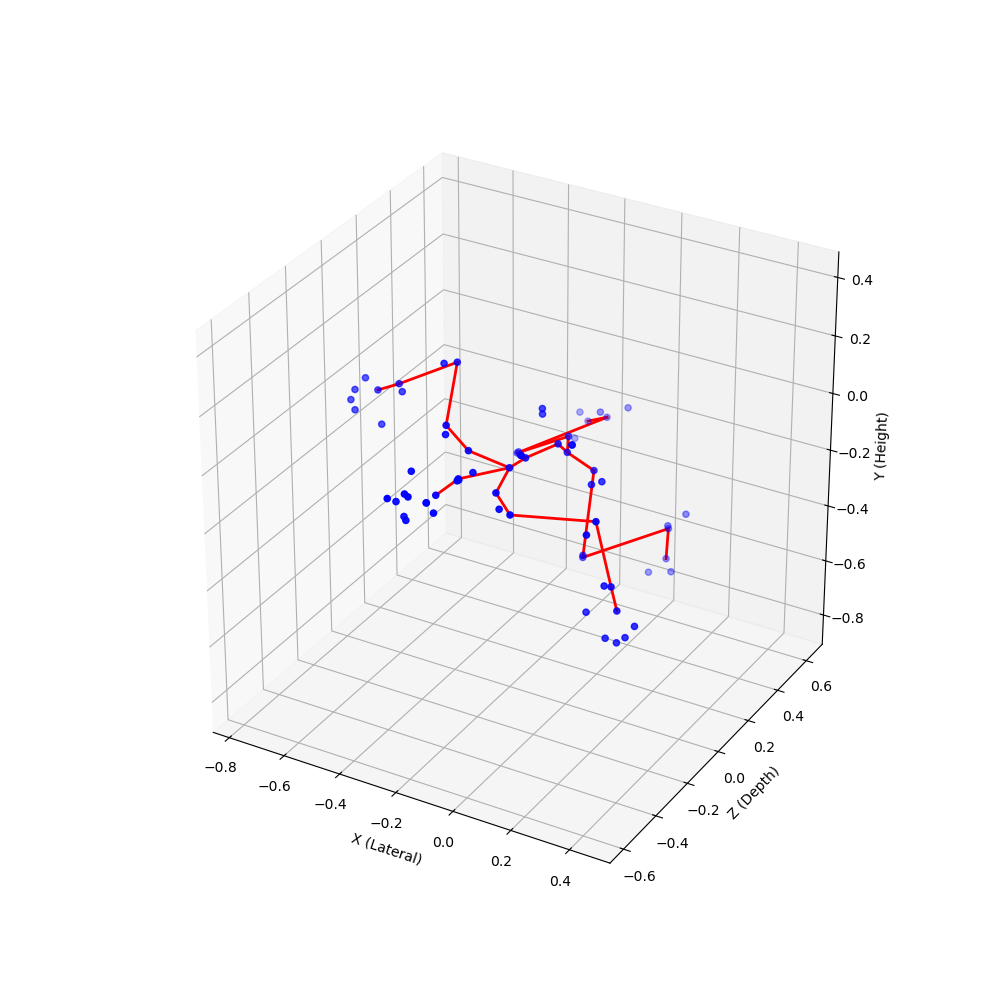

In [103]:
# Show 3D Coordinates

def plot_bev_skeleton(joints_3d, person_idx=0):
    person_joints = np.array(joints_3d[person_idx]).astype(float)
    if np.isnan(person_joints).any():
        person_joints = np.nan_to_num(person_joints)

    smpl_connections = [
        (0, 1), (0, 2), (0, 3), (1, 4), (4, 7), (7, 10), (2, 5), (5, 8), (8, 11),
        (3, 6), (6, 9), (9, 12), (12, 15), (9, 13), (13, 16), (16, 18), (18, 20),
        (20, 22), (9, 14), (14, 17), (17, 19), (19, 21), (21, 23)
    ]

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    x = person_joints[:, 0]
    y = -person_joints[:, 1]
    z = person_joints[:, 2]

    mid_x = (x.max() + x.min()) * 0.5
    mid_y = (y.max() + y.min()) * 0.5
    mid_z = (z.max() + z.min()) * 0.5
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_z - max_range, mid_z + max_range)
    ax.set_zlim(mid_y - max_range, mid_y + max_range)

    ax.set_box_aspect([1,1,1]) 

    ax.scatter(x, z, y, c='blue', s=20)
    for start, end in smpl_connections:
        ax.plot([x[start], x[end]], [z[start], z[end]], [y[start], y[end]], c='red', linewidth=2)

    ax.set_xlabel('X (Lateral)')
    ax.set_ylabel('Z (Depth)')
    ax.set_zlabel('Y (Height)')
    
    plt.show()

if joints is not None:
    plot_bev_skeleton(joints, person_idx=0)

### **Convert To Numpy**

In [104]:
# Create Numpy Arrays

keypoints_3d = joints[0].copy()

### **Compute Disparity Map**

In [105]:
# Load & Crop Images

image_A = cv2.imread(IMAGE_A_PATH)
image_B = cv2.imread(IMAGE_B_PATH)

gray_A_full = cv2.cvtColor(image_A, cv2.COLOR_BGR2GRAY)
gray_B_full = cv2.cvtColor(image_B, cv2.COLOR_BGR2GRAY)

In [106]:
# Crop Images

h, w = 480, 480
y_start, x_start = 300, 720

gray_A = gray_A_full[y_start:y_start+h, x_start:x_start+w]
gray_B = gray_B_full[y_start:y_start+h, x_start:x_start+w]

In [107]:
# Initialize SGBM object

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=160,
    blockSize=5,
    P1=8 * 3 * 5**2,
    P2=32 * 3 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=0,
    speckleRange=2,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

In [108]:
# Compute Disparity

start_time = time.perf_counter()

disparity = stereo.compute(gray_A, gray_B).astype(np.float32) / 16.0

end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Disparity took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Disparity took: 0.0120 seconds
FPS: 83.56


### **Calculate Camera-Shoulder Distnace**

In [109]:
# Get Predicted Right Shoulder Pixel Location

height, width = disparity.shape

shoulder_kp_2d = keypoints_2d[17]

px_x = int(np.clip(shoulder_kp_2d[0] * width, 0, width - 1))
px_y = int(np.clip(shoulder_kp_2d[1] * height, 0, height - 1))

window = disparity[px_y-2:px_y+3, px_x-2:px_x+3]
disp_at_shoulder = np.nanmedian(window) if np.any(window) else 0

print(disp_at_shoulder)

48.8125


In [110]:
# Calculate Focal Length

image_width_px = 1920
focal_length_px= (FOCAL_LENGTH_MM * image_width_px) / SENSOR_WIDTH_MM

In [111]:
# Distance Output

distance = None
if disp_at_shoulder > 0:
    distance = (focal_length_px * BASELINE_M) / disp_at_shoulder
    print(f"Distance to shoulder: {distance:.3f} meters")
else:
    print("Distance calculation failed: Disparity is zero or negative at center.")

Distance to shoulder: 3.824 meters


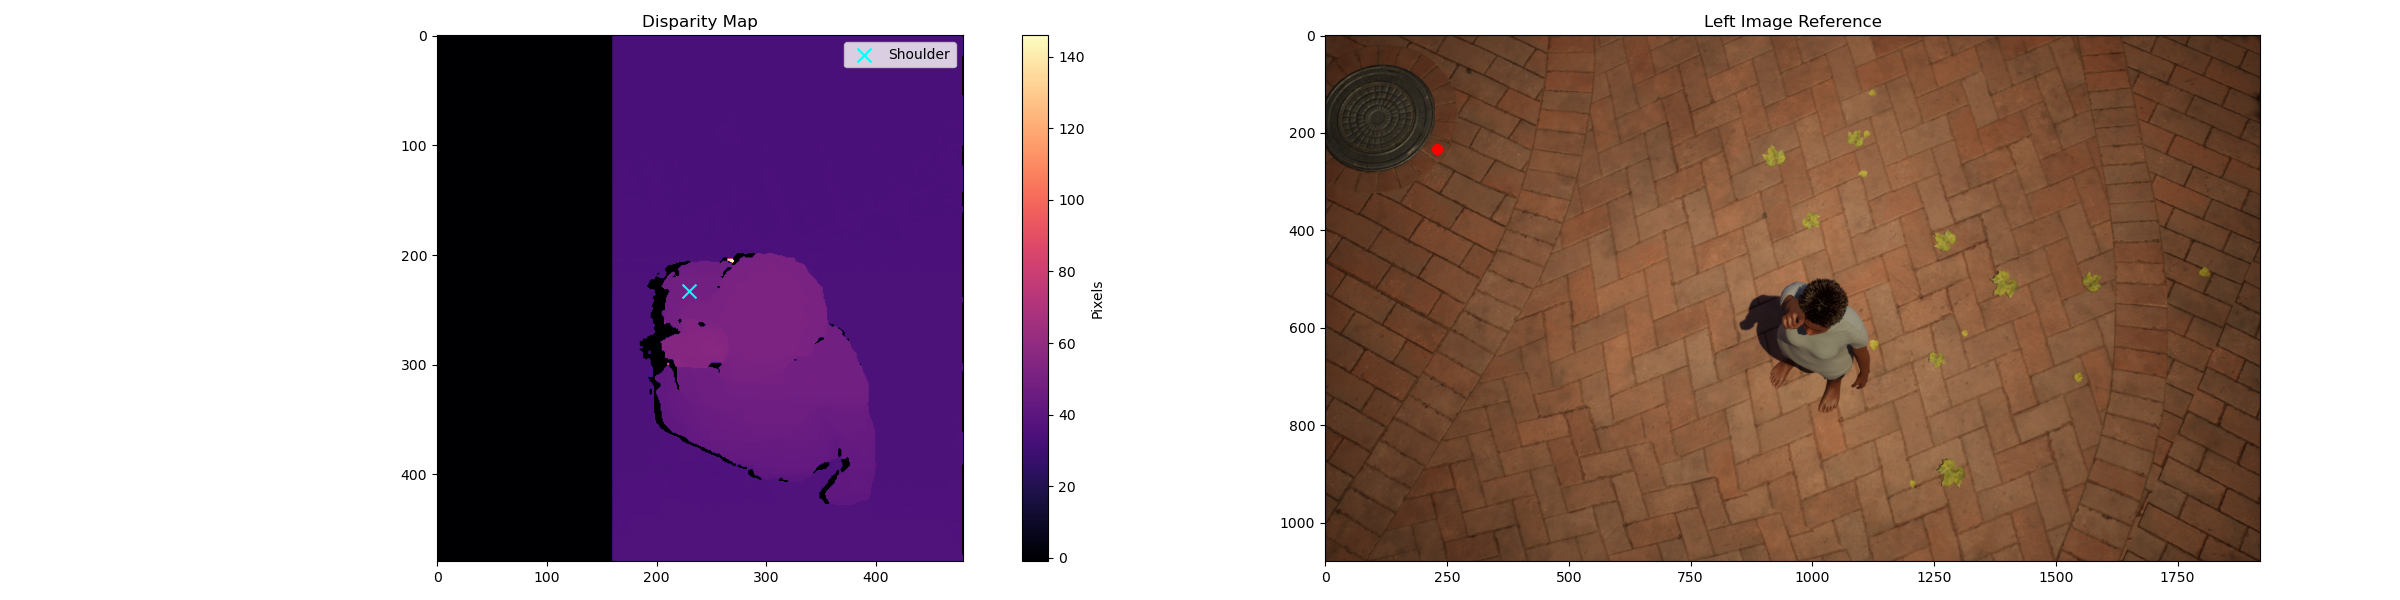

In [112]:
# Visualize Disparity

plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.title("Disparity Map")
plt.imshow(disparity, cmap='magma')
plt.colorbar(label='Pixels')
plt.scatter(px_x, px_y, color='cyan', marker='x', s=100, label='Shoulder')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Left Image Reference")
plt.imshow(cv2.cvtColor(image_A, cv2.COLOR_BGR2RGB))
plt.scatter(px_x, px_y, color='red', marker='o', s=50)

plt.tight_layout()
plt.show()

### **Place 3D Keypoints**

In [113]:
# Transform 3D Keypoints Given Distance

keypoints_3d_rel = keypoints_3d - keypoints_3d[17]
transformed_keypoints_3d = keypoints_3d_rel.copy()
transformed_keypoints_3d[:, 2] += distance

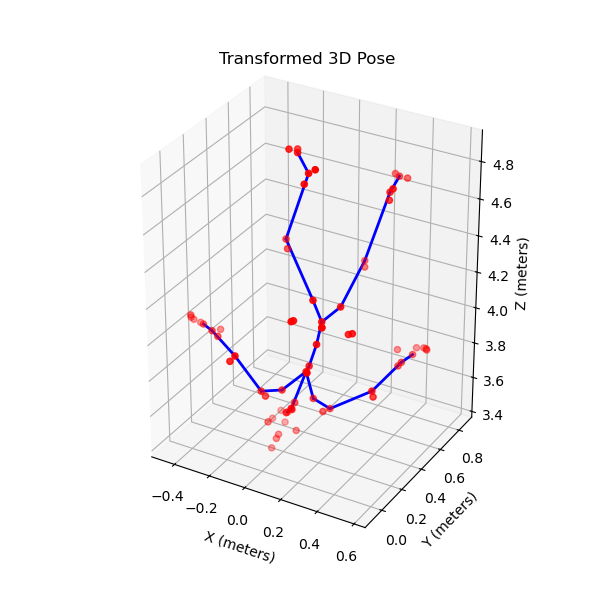

In [114]:
# Visualize Transformed 3D Keypoints

def plot_pose_3d(points_3d):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='r', marker='o')

    smpl_connections = [
        (0, 1), (0, 2), (0, 3), (1, 4), (4, 7), (7, 10), (2, 5), (5, 8), (8, 11),
        (3, 6), (6, 9), (9, 12), (12, 15), (9, 13), (13, 16), (16, 18), (18, 20),
        (20, 22), (9, 14), (14, 17), (17, 19), (19, 21), (21, 23)
    ]

    for connection in smpl_connections:
        start_idx, end_idx = connection
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='b', linewidth=2)

    ax.set_aspect('equal')
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_zlabel('Z (meters)')
    ax.set_title('Transformed 3D Pose')
    
    plt.show()

plot_pose_3d(transformed_keypoints_3d)

### **Convert To Unreal Engine Coordinates**

In [115]:
# Apply Coordinate Conversion

def convert_to_unreal_coords(points_3d_meters):
    unreal_pts = np.zeros_like(points_3d_meters)
    
    # UE X (Forward) = CV Z
    unreal_pts[:, 0] = points_3d_meters[:, 2] * 100
    
    # UE Y (Right) = CV X
    unreal_pts[:, 1] = points_3d_meters[:, 0] * 100
    
    # UE Z (Up) = -CV Y
    unreal_pts[:, 2] = -points_3d_meters[:, 1] * 100
    
    return unreal_pts

ue_keypoints_3d = convert_to_unreal_coords(transformed_keypoints_3d)

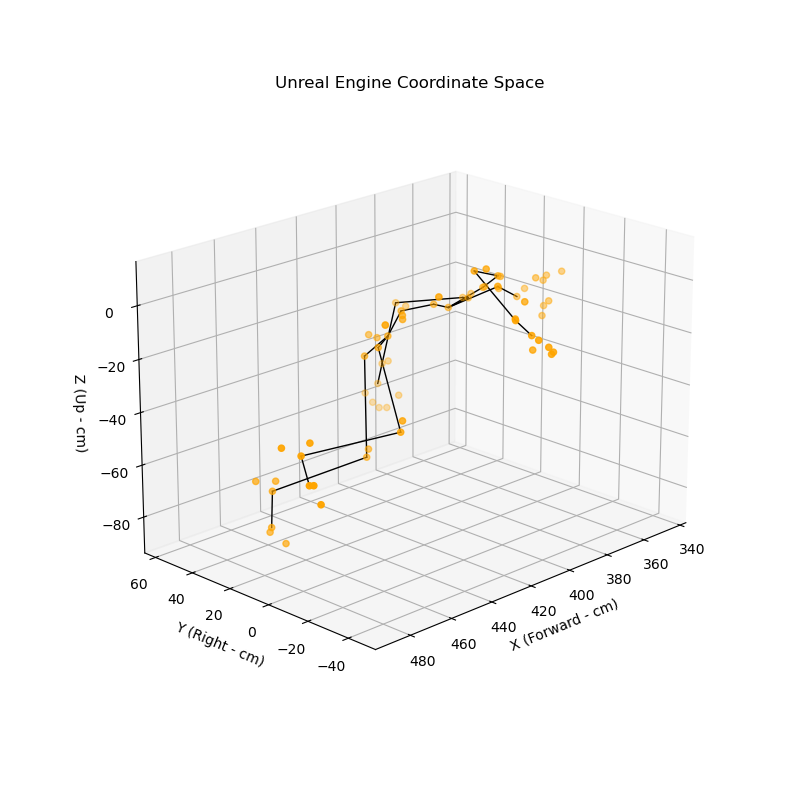

In [116]:
# Verify Coordinate Conversion

def plot_pose_unreal_3d(points_3d):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='orange', marker='o')
    
    smpl_connections = [
        (0, 1), (0, 2), (0, 3), (1, 4), (4, 7), (7, 10), (2, 5), (5, 8), (8, 11),
        (3, 6), (6, 9), (9, 12), (12, 15), (9, 13), (13, 16), (16, 18), (18, 20),
        (20, 22), (9, 14), (14, 17), (17, 19), (19, 21), (21, 23)
    ]

    for connection in smpl_connections:
        start_idx, end_idx = connection
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='black', linewidth=1)

    ax.set_xlabel('X (Forward - cm)')
    ax.set_ylabel('Y (Right - cm)')
    ax.set_zlabel('Z (Up - cm)')
    ax.set_title('Unreal Engine Coordinate Space')

    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    ax.view_init(elev=20, azim=45)
    
    plt.show()

plot_pose_unreal_3d(ue_keypoints_3d)

### **Compute Output Vector**

In [117]:
# Given Constants

camera_coords = np.array([0, 0, 0])
world_up = np.array([0, 0, 1])
camera_pitch_rad = np.deg2rad(-76.16348683834077)

In [118]:
# Get Right Shoulder & Wrist Coordinates

shoulder_coords = ue_keypoints_3d[17]
wrist_coords = ue_keypoints_3d[21]

print(shoulder_coords)
print(wrist_coords)

[382.4157   0.      -0.    ]
[404.60214   -29.858038   -4.5788617]


In [119]:
# Shoulder-Camera Distance

distance = np.linalg.norm(shoulder_coords)
print(distance, "cm")

382.4157 cm


In [120]:
# Shoulder-Wrist Shoulder-Camera Vectors

shoulder_wrist = wrist_coords - shoulder_coords
shoulder_wrist /= np.linalg.norm(shoulder_wrist)

shoulder_camera = camera_coords - shoulder_coords
shoulder_camera /= np.linalg.norm(shoulder_camera)

print(shoulder_wrist)
print(shoulder_camera)

[ 0.59196323 -0.7966518  -0.12217006]
[-1.  0.  0.]


In [121]:
# Angular Separation

angular_separation_rad = np.arccos(np.clip(np.dot(shoulder_wrist, shoulder_camera), -1.0, 1.0))
angular_separation_deg = np.rad2deg(angular_separation_rad)

print(angular_separation_deg, "deg")


126.29644918694625 deg


In [122]:
# Camera Un-Pitch Matrix (Aligns Z-Axis with Gravity)

c, s = np.cos(-camera_pitch_rad), np.sin(-camera_pitch_rad)
unpitch_matrix = np.array([
    [c,  0, s],
    [0,  1, 0],
    [-s, 0, c]
])
print(unpitch_matrix)

[[ 0.23915229  0.          0.97098207]
 [ 0.          1.          0.        ]
 [-0.97098207  0.          0.23915229]]


In [123]:
# Un-Pitch Vectors

shoulder_wrist_gravity = unpitch_matrix @ shoulder_wrist
shoulder_wrist_gravity /= np.linalg.norm(shoulder_wrist_gravity)

shoulder_camera_gravity = unpitch_matrix @ shoulder_camera
shoulder_camera_gravity /= np.linalg.norm(shoulder_camera_gravity)

print(shoulder_wrist_gravity)
print(shoulder_camera_gravity)

[ 0.02294442 -0.79665176 -0.60400292]
[-0.23915229  0.          0.97098207]


In [124]:
# Yaw & Pitch Components

shoulder_wrist_gravity_yaw = np.rad2deg(np.atan2(shoulder_wrist_gravity[1], shoulder_wrist_gravity[0]))
shoulder_wrist_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_wrist_gravity[-1], -1.0, 1.0)))

shoulder_camera_gravity_yaw = np.rad2deg(np.atan2(shoulder_camera_gravity[1], shoulder_camera_gravity[0]))
shoulder_camera_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_camera_gravity[-1], -1.0, 1.0)))

delta_yaw = (shoulder_wrist_gravity_yaw - shoulder_camera_gravity_yaw + 180) % 360 - 180
delta_pitch = shoulder_wrist_gravity_pitch - shoulder_camera_gravity_pitch

print(delta_yaw)
print(delta_pitch)

91.64972364531917
-113.32061360962507
